# Data Transformation and Feature Engineering

**Goal:** turn cleaned BTS records into useful operational summaries and a documented candidate feature set for predicting arrival delays **over 60 minutes** before departure.

Run `python scripts/run_etl.py` first, then **Run All** in this notebook. Notebook 01 explains cleaning and EDA. Here we work through one full month using ordinary pandas/NumPy operations; the production script applies the same functions to all 12 months and saves the outputs. Full-year summaries and reconciliation are checked at the end.

A transformation changes the representation of data; a feature is a column that may help answer a question. We will demonstrate both **many-to-one merges** and a **group-by/pivot**, plus route, calendar, distance-band, scheduled-hour, and cyclic-time features. No models or learned preprocessing are fitted.

In [1]:
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "airline-matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_FOLDER = Path.cwd()
if PROJECT_FOLDER.name == "notebooks":
    PROJECT_FOLDER = PROJECT_FOLDER.parent
sys.path.insert(0, str(PROJECT_FOLDER))

from src.clean import scheduled_hour, departure_time_band
from src.config import load_settings
from src.features import (
    add_features, chronological_split, join_airports, select_ml_rows,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, MODEL_FEATURES, ML_METADATA, BLOCKED_FEATURES,
)

settings = load_settings()
TABLE_FOLDER = PROJECT_FOLDER / "reports/tables"
FIGURE_FOLDER = PROJECT_FOLDER / "reports/figures"
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
assert (TABLE_FOLDER / "final_row_reconciliation.csv").exists(), "Run python scripts/run_etl.py first."

## 1. Load a cleaned monthly partition

We keep one row per scheduled flight and preserve source filename + data-row number. Cancellations and diversions remain in the operational table. The ML view later selects only rows with a valid target.

Parquet saves types and takes less disk space than repeatedly copying the large CSVs. It is a storage format; the transformations are still ordinary pandas code.

In [2]:
clean_path = PROJECT_FOLDER / "data/interim/flights_standardized/2025_01.parquet"
flights = pd.read_parquet(clean_path)
airports = pd.read_csv(PROJECT_FOLDER / "data/interim/airports_standardized/airports_standardized.csv")
print("January cleaned shape:", flights.shape)
display(flights.head())
assert not flights.duplicated(["source_file", "source_row_number"]).any()
assert airports["iata_code"].is_unique
display(airports.head())

January cleaned shape: (539747, 42)


,year,quarter,month,day_of_month,day_of_week,flight_date,reporting_airline,flight_number,origin,destination,...,route,scheduled_dep_hour,departure_time_band,is_weekend,season,ml_target_eligible,completed_missing_arrival_delay,severe_delay,delay_category,source_row_number
0,2025,1,1,1,3,2025-01-01,AA,1,JFK,LAX,...,JFK-LAX,6,Morning,0,Winter,1,0,0,On Time / Early,1
1,2025,1,1,1,3,2025-01-01,AA,10,LAX,JFK,...,LAX-JFK,22,Night,0,Winter,1,0,0,On Time / Early,2
2,2025,1,1,1,3,2025-01-01,AA,1002,MSN,CLT,...,MSN-CLT,6,Morning,0,Winter,1,0,0,Moderate Delay,3
3,2025,1,1,1,3,2025-01-01,AA,1004,PHL,LAS,...,PHL-LAS,18,Evening,0,Winter,1,0,0,On Time / Early,4
4,2025,1,1,1,3,2025-01-01,AA,1005,ORD,PHX,...,ORD-PHX,8,Morning,0,Winter,1,0,0,Moderate Delay,5


,iata_code,source_iata_code,ident,name,type,latitude_deg,longitude_deg,elevation_ft,iso_country,iso_region,municipality,scheduled_service
0,AAA,AAA,NTGA,Anaa Airport,medium_airport,-17.352600,-145.509995,10.0,PF,PF-U-A,Anaa,YES
1,AAB,AAB,YARY,Arrabury Airport,small_airport,-26.696390,141.048718,334.0,AU,AU-QLD,Tanbar,NO
2,AAC,AAC,HEAR,El Arish International Airport,large_airport,31.055324,33.827964,118.0,EG,EG-SIN,El Arish,YES
3,AAD,AAD,AAD,Adado Airport,small_airport,6.095802,46.637500,1001.0,SO,SO-GA,Adado,NO
4,AAE,AAE,DABB,Annaba Rabah Bitat Airport,large_airport,36.826781,7.813340,16.0,DZ,DZ-23,Annaba,YES


## 2. Route and calendar features

A direction matters: JFK–LAX and LAX–JFK are different routes. Route supports both route-level operational comparisons and later categorical modeling.

Day of week, weekend, month, quarter, and season represent recurring schedule patterns. BTS uses Monday=1 through Sunday=7. The ETL verifies these source calendar columns against the parsed date before saving; the demonstration below derives them directly from the date.

Season is a simple Northern Hemisphere calendar grouping, not a weather measurement.

In [3]:
demo = flights.copy()
demo["route"] = demo["origin"] + "-" + demo["destination"]
demo["day_of_week"] = demo["flight_date"].dt.dayofweek + 1
demo["is_weekend"] = demo["day_of_week"].isin([6, 7]).astype("Int8")
demo["month"] = demo["flight_date"].dt.month
demo["quarter"] = demo["flight_date"].dt.quarter
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}
demo["season"] = demo["month"].map(season_map)
display(demo[["flight_date", "route", "day_of_week", "is_weekend", "month", "quarter", "season"]].head())

,flight_date,route,day_of_week,is_weekend,month,quarter,season
0,2025-01-01,JFK-LAX,3,0,1,1,Winter
1,2025-01-01,LAX-JFK,3,0,1,1,Winter
2,2025-01-01,MSN-CLT,3,0,1,1,Winter
3,2025-01-01,PHL-LAS,3,0,1,1,Winter
4,2025-01-01,ORD-PHX,3,0,1,1,Winter


## 3. Scheduled time and cyclic time

BTS scheduled times are HHMM numbers: 5 means 00:05; 1730 means 17:30; 2400 maps to midnight hour 0. Minutes must be 00–59 and fractional clock values are invalid. We do not shift the flight-date label for 2400 in these hour-of-day features.

Use scheduled times because they are available before departure. Actual times and delays reveal the outcome and are excluded from predictors. Do not subtract arrival and departure local clocks to estimate duration: airports may be in different time zones. Use the source scheduled elapsed duration.

The hour number alone puts 23 and 0 far apart. Sine and cosine place a day's clock on a circle so times just before/after midnight have similar coordinates. Both columns together preserve the position around the clock.

In [4]:
demo["scheduled_dep_hour"] = scheduled_hour(demo["crs_dep_time"])
demo["scheduled_arr_hour"] = scheduled_hour(demo["crs_arr_time"])
demo["departure_time_band"] = departure_time_band(
    demo["scheduled_dep_hour"], settings["features"]["departure_time_bands"]
)
minutes_after_midnight = demo["scheduled_dep_hour"] * 60.0 + demo["crs_dep_time"] % 100
angle = 2 * np.pi * minutes_after_midnight.astype(float) / 1440
demo["dep_time_sin"] = np.sin(angle)
demo["dep_time_cos"] = np.cos(angle)

clock_examples = pd.Series([5, 559, 600, 1730, 2359, 2400, 1260, 600.5, np.nan])
display(pd.DataFrame({"HHMM": clock_examples, "parsed_hour": scheduled_hour(clock_examples)}))
display(demo[["crs_dep_time", "scheduled_dep_hour", "departure_time_band", "dep_time_sin", "dep_time_cos"]].head())

,HHMM,parsed_hour
0,5.0,0
1,559.0,5
2,600.0,6
3,1730.0,17
4,2359.0,23
5,2400.0,0
6,1260.0,<NA>
7,600.5,<NA>
8,NaN,<NA>


,crs_dep_time,scheduled_dep_hour,departure_time_band,dep_time_sin,dep_time_cos
0,659,6,Morning,0.967046,-0.254602
1,2200,22,Night,-0.500000,0.866025
2,644,6,Morning,0.981627,-0.190809
3,1855,18,Evening,-0.971342,0.237686
4,830,8,Morning,0.793353,-0.608761


## 4. Distance bands

The continuous distance remains available. The extra band provides a simple comparison of short, medium, and long routes: **Short: 0 < miles ≤ 500**, **Medium: 500 < miles ≤ 1500**, **Long: miles > 1500**. These are transparent project choices, not an official aviation classification.

The feature may capture differences between flight lengths, but we have not shown that it improves prediction. Encoding and feature selection belong to later training/validation.

In [5]:
demo["distance_band"] = pd.cut(
    demo["distance_miles"], bins=[0, 500, 1500, np.inf],
    labels=["Short", "Medium", "Long"]
).astype("string")
display(demo[["distance_miles", "distance_band"]].head())
display(demo["distance_band"].value_counts())

# Confirm the teaching operations agree with the reusable full-data function.
engineered = add_features(flights, settings)
for column in ["route", "is_weekend", "season", "scheduled_dep_hour", "scheduled_arr_hour",
               "departure_time_band", "distance_band", "dep_time_sin", "dep_time_cos"]:
    pd.testing.assert_series_equal(demo[column], engineered[column], check_dtype=False)
del demo
print("Demonstration matches production features.")

,distance_miles,distance_band
0,2475.0,Long
1,2475.0,Long
2,708.0,Medium
3,2176.0,Long
4,1440.0,Medium


distance_band
Medium    287577
Short     182491
Long       69679
Name: count, dtype: Int64

Demonstration matches production features.


## 5. Enrich both flight endpoints: two many-to-one joins

The airport source has one lookup record per valid IATA code after standardization. We join it once for the origin and again for the destination. A left join preserves every flight; `validate="many_to_one"` rejects a duplicate lookup code that would multiply rows.

The supplied reference snapshot uses DJT for the record matched to BTS PBI. The existing documented alias preserves **PBI in historical flight records**, and stores **DJT as source_iata_code**. Names and regions are current snapshot labels, not a versioned 2025 dimension. We only allow physical latitude/longitude as candidate static predictors, acknowledging that a dated 2025 airport reference would be preferable.

In [6]:
airport_columns = ["iata_code", "source_iata_code", "ident", "name",
                   "iso_region", "latitude_deg", "longitude_deg"]
origin_lookup = airports[airport_columns].rename(columns={
    column: "origin" if column == "iata_code" else "origin_" + column
    for column in airport_columns
})
destination_lookup = airports[airport_columns].rename(columns={
    column: "destination" if column == "iata_code" else "destination_" + column
    for column in airport_columns
})

enriched = engineered.merge(origin_lookup, on="origin", how="left", validate="many_to_one", indicator=True)
assert enriched["_merge"].eq("both").all()
enriched = enriched.drop(columns="_merge")
enriched = enriched.merge(destination_lookup, on="destination", how="left", validate="many_to_one", indicator=True)
assert enriched["_merge"].eq("both").all()
enriched = enriched.drop(columns="_merge")
enriched["origin"] = enriched["origin"].astype("string")
enriched["destination"] = enriched["destination"].astype("string")
assert len(enriched) == len(flights)
pd.testing.assert_frame_equal(enriched, join_airports(engineered, airports))
display(enriched[["origin", "origin_name", "origin_latitude_deg", "destination", "destination_name"]].head())
display(airports.loc[airports["iata_code"].isin(["PBI", "DJT"]), ["iata_code", "source_iata_code", "ident", "name"]])
display(pd.read_csv(TABLE_FOLDER / "airport_join_coverage.csv"))
del engineered

,origin,origin_name,origin_latitude_deg,destination,destination_name
0,JFK,John F. Kennedy International Airport,40.639447,LAX,Los Angeles International Airport
1,LAX,Los Angeles International Airport,33.942501,JFK,John F. Kennedy International Airport
2,MSN,Dane County Regional Truax Field,43.139900,CLT,Charlotte Douglas International Airport
3,PHL,Philadelphia International Airport,39.871899,LAS,Harry Reid International Airport
4,ORD,Chicago O'Hare International Airport,41.978600,PHX,Phoenix Sky Harbor International Airport


,iata_code,source_iata_code,ident,name
1810,DJT,DJT,KPBI,President Donald J. Trump International Airport
9056,PBI,DJT,KPBI,President Donald J. Trump International Airport


,perspective,distinct_bts_codes,matched_codes,distinct_code_match_rate,total_flight_rows,unmatched_flight_rows,flight_row_match_rate
0,origin,352,352,1.0,7001619,0,1.0
1,destination,352,352,1.0,7001619,0,1.0


## 6. Non-trivial aggregation: route performance

Group by route and calculate counts and rates. `size` counts every scheduled record, `count` counts only non-null targets, and `sum` counts the severe targets. The severe-delay denominator is eligible flights; the cancellation denominator is all scheduled flights.

This table is descriptive. Its arrival-delay outcome aggregates are **not** merged into predictor rows: full-month or full-year route averages would reveal future outcomes. Historical features are intentionally deferred.

In [7]:
january_routes = enriched.groupby("route", as_index=False).agg(
    total_flights=("route", "size"),
    eligible_flights=("severe_delay", "count"),
    severe_count=("severe_delay", "sum"),
    cancelled_flights=("cancelled", "sum"),
    mean_arrival_delay=("arrival_delay_minutes", "mean"),
)
january_routes["severe_delay_rate"] = (
    january_routes["severe_count"] / january_routes["eligible_flights"].replace(0, np.nan)
)
january_routes["cancellation_rate"] = january_routes["cancelled_flights"] / january_routes["total_flights"]
assert january_routes["total_flights"].sum() == len(enriched)
display(january_routes.nlargest(10, "total_flights"))
# Validate the full pipeline's independently generated January counts.
stored_routes = pd.read_csv(TABLE_FOLDER / "route_month_performance.csv")
stored_january = stored_routes.loc[stored_routes["month"].eq(1)].sort_values("route")
for column in ["total_flights", "eligible_flights", "severe_count", "cancelled_flights"]:
    np.testing.assert_array_equal(january_routes.sort_values("route")[column], stored_january[column])

,route,total_flights,eligible_flights,severe_count,cancelled_flights,mean_arrival_delay,severe_delay_rate,cancellation_rate
3702,OGG-HNL,986,965,31,20,3.808290,0.032124,0.020284
2225,HNL-OGG,985,964,30,21,2.190871,0.03112,0.02132
3870,ORD-LGA,923,905,76,14,2.993370,0.083978,0.015168
2987,LGA-ORD,919,902,49,17,-0.951220,0.054324,0.018498
2897,LAX-SFO,852,851,35,1,-3.725029,0.041128,0.001174
4999,SFO-LAX,849,847,29,0,-0.136954,0.034238,0.0
4176,PHX-DEN,806,803,29,2,1.657534,0.036115,0.002481
1418,DEN-PHX,800,798,45,2,0.052632,0.056391,0.0025
585,BOS-DCA,776,715,45,59,0.826573,0.062937,0.076031
2861,LAX-JFK,775,767,34,3,-9.129074,0.044329,0.003871


## 7. Non-trivial reshape: route-by-month matrix

The stored route-month table was grouped from every flight in each monthly partition. Select the ten busiest routes by full-year scheduled volume and pivot their severe-delay rates. Months without an eligible outcome remain missing. This answers whether a route's observed delay risk changes through the year; it is not a model input.

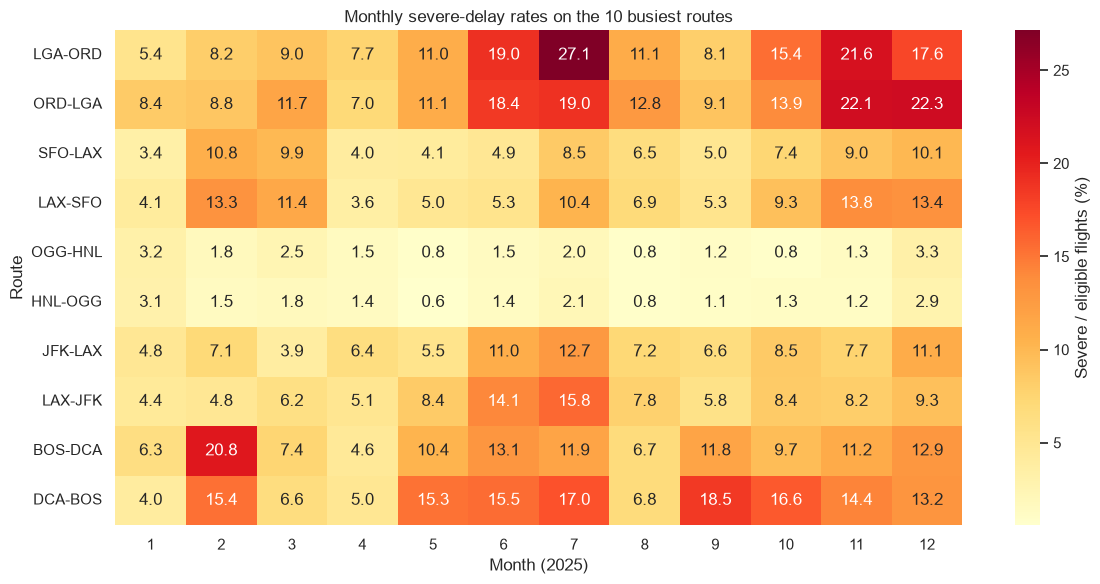

In [8]:
full_routes = pd.read_csv(TABLE_FOLDER / "route_performance.csv")
busy_routes = full_routes.nlargest(10, "total_flights")["route"]
route_matrix = stored_routes.loc[stored_routes["route"].isin(busy_routes)].pivot(
    index="route", columns="month", values="severe_delay_rate"
).reindex(busy_routes)

plt.figure(figsize=(12, 6))
sns.heatmap(route_matrix * 100, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "Severe / eligible flights (%)"})
plt.title("Monthly severe-delay rates on the 10 busiest routes")
plt.xlabel("Month (2025)")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "route_month_severe_delay.png", dpi=160)
plt.show()

## 8. Target and leakage-safe predictor selection

`severe_delay` is a label, never an input feature. Cancellation/diversion and target-eligibility flags are useful for selecting rows, but not for predicting the outcome before departure. The completed-flight missing-outcome flag is blocked for the same reason.

`scheduled_elapsed_invalid` is allowed because it describes an invalid schedule value, not the observed flight outcome. Retain the missing duration so a later imputer can learn a replacement from training rows only.

Explicit feature lists prevent accidental inclusion of actual departure/arrival times, operational delays, cause minutes, or full-year outcome summaries. The following dataset is ready for later preprocessing; it is not a fully encoded or imputed modeling matrix.

In [9]:
assert not set(MODEL_FEATURES) & set(BLOCKED_FEATURES)
print("Numeric candidate features:", NUMERIC_FEATURES)
print("Categorical candidate features:", CATEGORICAL_FEATURES)
print("Metadata excluded from X:", ML_METADATA)
print("Blocked outcome columns:", BLOCKED_FEATURES)

eligible = enriched["ml_target_eligible"].eq(1)
ml_january = select_ml_rows(enriched)
X_example = ml_january[MODEL_FEATURES]
y_example = ml_january["severe_delay"]
assert y_example.isin([0, 1]).all()
assert enriched.loc[~eligible, "severe_delay"].isna().all()
expected_y = enriched.loc[eligible, "arrival_delay_minutes"].gt(60).astype("Int8")
pd.testing.assert_series_equal(y_example, expected_y, check_names=False)
print("January operational rows:", len(enriched))
print("January eligible ML rows:", len(ml_january))
print("January severe-delay rate:", f"{y_example.mean():.2%}")
display(X_example.head())

Numeric candidate features: ['month', 'quarter', 'day_of_week', 'day_of_month', 'is_weekend', 'scheduled_dep_hour', 'scheduled_arr_hour', 'distance_miles', 'scheduled_elapsed_minutes', 'scheduled_elapsed_invalid', 'dep_time_sin', 'dep_time_cos', 'origin_latitude_deg', 'origin_longitude_deg', 'destination_latitude_deg', 'destination_longitude_deg']
Categorical candidate features: ['reporting_airline', 'origin', 'destination', 'route', 'departure_time_band', 'season', 'distance_band']
Metadata excluded from X: ['flight_date', 'source_file', 'source_row_number', 'dataset_split']
Blocked outcome columns: ['dep_time', 'departure_delay_minutes', 'arr_time', 'arrival_delay_minutes', 'actual_elapsed_minutes', 'air_time_minutes', 'cancelled', 'diverted', 'cancellation_code', 'carrier_delay_minutes', 'weather_delay_minutes', 'nas_delay_minutes', 'security_delay_minutes', 'late_aircraft_delay_minutes', 'delay_category', 'ml_target_eligible', 'completed_missing_arrival_delay', 'severe_delay']
Janu

,month,quarter,day_of_week,day_of_month,is_weekend,scheduled_dep_hour,scheduled_arr_hour,distance_miles,scheduled_elapsed_minutes,scheduled_elapsed_invalid,...,origin_longitude_deg,destination_latitude_deg,destination_longitude_deg,reporting_airline,origin,destination,route,departure_time_band,season,distance_band
0,1,1,3,1,0,6,10,2475.0,381.0,0,...,-73.779317,33.942501,-118.407997,AA,JFK,LAX,JFK-LAX,Morning,Winter,Long
1,1,1,3,1,0,22,6,2475.0,330.0,0,...,-118.407997,40.639447,-73.779317,AA,LAX,JFK,LAX-JFK,Night,Winter,Long
2,1,1,3,1,0,6,10,708.0,141.0,0,...,-89.337502,35.214001,-80.943100,AA,MSN,CLT,MSN-CLT,Morning,Winter,Medium
3,1,1,3,1,0,18,21,2176.0,339.0,0,...,-75.241096,36.083361,-115.151817,AA,PHL,LAS,PHL-LAS,Evening,Winter,Long
4,1,1,3,1,0,8,11,1440.0,241.0,0,...,-87.904800,33.435302,-112.005905,AA,ORD,PHX,ORD-PHX,Morning,Winter,Medium


## 9. Freeze chronological splits before training

Training: **1 January–31 August**; validation: **1 September–31 October**; testing: **1 November–31 December 2025**. Do not randomly mix future and past rows.

Dates and provenance accompany the saved rows but are not in `MODEL_FEATURES`. A model notebook should split first, fit encoders/imputers/scalers on training data, use validation for model choices, and evaluate the selected model on test data. Keep natural class proportions in validation/testing. Unknown future categories will need an encoder that can handle them.

The split summary measures prevalence; no preprocessing or balancing has occurred. The full-year descriptive EDA does include holdout outcomes, a limitation to acknowledge when reporting later evaluation.

In [10]:
boundary_dates = pd.Series(pd.to_datetime([
    "2025-01-01", "2025-08-31", "2025-09-01",
    "2025-10-31", "2025-11-01", "2025-12-31",
]))
display(pd.DataFrame({"flight_date": boundary_dates,
                      "dataset_split": chronological_split(boundary_dates, settings)}))
split_summary = pd.read_csv(TABLE_FOLDER / "ml_split_summary.csv")
display(split_summary)
display(ml_january["dataset_split"].value_counts())

,flight_date,dataset_split
0,2025-01-01,train
1,2025-08-31,train
2,2025-09-01,validation
3,2025-10-31,validation
4,2025-11-01,test
5,2025-12-31,test


,dataset_split,operational_rows,eligible_rows,severe_count,min_date,max_date,severe_delay_rate
0,test,1152854,1127220,98647,2025-11-01,2025-12-31,0.087514
1,train,4680482,4592366,387319,2025-01-01,2025-08-31,0.084340
2,validation,1168283,1159898,67042,2025-09-01,2025-10-31,0.057800


dataset_split
train    522269
Name: count, dtype: Int64

## 10. Verify persisted outputs and data dictionary

The full ETL writes a cleaned operational partition, an enriched partition, and an eligible ML partition for each month, then reads each back to check row identity and target values. Here we verify the published file set and reconciliation. To reproduce all 12 months from raw inputs, run `python scripts/run_etl.py` again.

The data dictionary describes stored types and each column's role. Candidate numeric and categorical features are intentionally kept in their readable form for the next stage.

In [11]:
reconciliation = pd.read_csv(TABLE_FOLDER / "final_row_reconciliation.csv")
display(reconciliation)
expected_names = {f"2025_{month:02d}.parquet" for month in range(1, 13)}
for folder in ["data/interim/flights_standardized",
               "data/processed/flights_wrangled", "data/processed/flights_ml"]:
    names = {path.name for path in (PROJECT_FOLDER / folder).glob("*.parquet")}
    assert names == expected_names, f"Missing or unexpected partitions: {folder}"
assert reconciliation["raw_rows"].equals(reconciliation["cleaned_rows"])
assert reconciliation["raw_rows"].equals(reconciliation["enriched_rows"])
assert reconciliation["ml_rows"].sum() == split_summary["eligible_rows"].sum()
saved_ml = pd.read_parquet(PROJECT_FOLDER / "data/processed/flights_ml/2025_01.parquet")
pd.testing.assert_frame_equal(saved_ml, ml_january.reset_index(drop=True))
display(pd.read_csv(TABLE_FOLDER / "data_dictionary.csv"))
print("All 12 monthly partitions per layer found; January feature output matches the walkthrough.")
print("Total operational rows:", f"{reconciliation['enriched_rows'].sum():,}")
print("Total eligible rows:", f"{reconciliation['ml_rows'].sum():,}")
del saved_ml, flights, enriched, ml_january, X_example, y_example

,month,raw_rows,cleaned_rows,enriched_rows,ml_rows,excluded_from_ml,severe_count,dataset_split,min_date,max_date,exact_duplicates,business_key_duplicates,unmatched_origin,unmatched_destination
0,1,539747,539747,539747,522269,17478,32679,train,2025-01-01,2025-01-31,0,0,0,0
1,2,504884,504884,504884,496476,8408,36246,train,2025-02-01,2025-02-28,0,0,0,0
2,3,600872,600872,600872,592301,8571,41186,train,2025-03-01,2025-03-31,0,0,0,0
3,4,583950,583950,583950,577730,6220,38364,train,2025-04-01,2025-04-30,0,0,0,0
4,5,605648,605648,605648,597574,8074,51247,train,2025-05-01,2025-05-31,0,0,0,0
5,6,611575,611575,611575,599472,12103,66735,train,2025-06-01,2025-06-30,0,0,0,0
6,7,631428,631428,631428,612811,18617,72885,train,2025-07-01,2025-07-31,0,0,0,0
7,8,602378,602378,602378,593733,8645,47977,train,2025-08-01,2025-08-31,0,0,0,0
8,9,562439,562439,562439,558328,4111,29728,validation,2025-09-01,2025-09-30,0,0,0,0
9,10,605844,605844,605844,601570,4274,37314,validation,2025-10-01,2025-10-31,0,0,0,0


,column,dtype,role
0,year,Int64,descriptive / audit only
1,quarter,Int64,candidate predictor
2,month,Int64,candidate predictor
3,day_of_month,Int64,candidate predictor
4,day_of_week,Int64,candidate predictor
5,flight_date,datetime64[ns],"metadata, excluded from X"
6,reporting_airline,string,candidate predictor
7,flight_number,Int64,descriptive / audit only
8,origin,string,candidate predictor
9,destination,string,candidate predictor


All 12 monthly partitions per layer found; January feature output matches the walkthrough.
Total operational rows: 7,001,619
Total eligible rows: 6,879,484


## What this stage delivers

The project now has justified cleaning decisions, two endpoint airport merges, route/month group-by and pivot transformations, and multiple explained features supporting the research question. All operational records are preserved; eligible ML rows have the frozen target and split.

See `reports/feature_dictionary.md` for definitions and `reports/transformation_report.md` for measured results. Next steps are the SQLite warehouse and the separate ML notebook. Do not claim predictive improvement from feature engineering until models are evaluated. Current airport metadata and the single-year data scope remain limitations.